# Business Sales Performance Analytics
**Author:** Mercy Cherono  
**CIN:** FIT/MAR26/DS14325  
**Date:** March 2026  
**Dataset:** Superstore Sales Dataset (Kaggle)  

## Project Overview
Analysis of US retail sales data (2014–2017) to identify revenue trends,
top products, category performance, and regional insights.

## Table of Contents
1. Data Loading & Exploration
2. Data Cleaning
3. KPI Summary
4. Revenue Trend Analysis
5. Category Analysis
6. Regional Performance
7. Top Products
8. Insights & Recommendations

In [25]:
pip install pandas matplotlib seaborn jupyter

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [48]:
df = pd.read_csv("Sample - Superstore.xls", encoding='latin1')

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [28]:
# =====================
# DATA CLEANING & QUALITY CHECK
# =====================
print("=" * 40)
print("DATA QUALITY REPORT")
print("=" * 40)
print(f"Total Rows:        {df.shape[0]:,}")
print(f"Total Columns:     {df.shape[1]}")
print(f"Duplicate Rows:    {df.duplicated().sum()}")
print(f"Missing Values:    {df.isnull().sum().sum()}")
print(f"Negative Sales:    {(df['Sales'] < 0).sum()}")
print(f"Negative Profits:  {(df['Profit'] < 0).sum()}")
print("=" * 40)

# Show missing values per column
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("✅ No missing values found!")
else:
    print("⚠️ Missing values found:")
    print(missing)

DATA QUALITY REPORT
Total Rows:        9,994
Total Columns:     21
Duplicate Rows:    0
Missing Values:    0
Negative Sales:    0
Negative Profits:  1871
✅ No missing values found!


##  

- **No duplicates** found in the dataset
- **No missing values** detected across all 26 columns
- **No negative sales** values — data integrity confirmed
- **1,871 transactions show negative profit** — this is expected behavior
  caused by high discount rates (up to 80%) on certain products,
  particularly in the Furniture category. These are retained as they
  represent real business scenarios and form part of our analysis.

## Section 1: Executive KPI Summary
Key business performance indicators for the Superstore (2014–2017).

In [29]:
# =====================
# KPI SUMMARY
# =====================
total_revenue = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
profit_margin = (total_profit / total_revenue) * 100
avg_order_value = total_revenue / total_orders

print("=" * 45)
print("      EXECUTIVE KPI SUMMARY")
print("=" * 45)
print(f"  Total Revenue:      ${total_revenue:>12,.2f}")
print(f"  Total Profit:       ${total_profit:>12,.2f}")
print(f"  Profit Margin:      {profit_margin:>12.2f}%")
print(f"  Total Orders:       {total_orders:>13,}")
print(f"  Total Customers:    {total_customers:>13,}")
print(f"  Avg Order Value:    ${avg_order_value:>12,.2f}")
print("=" * 45)

      EXECUTIVE KPI SUMMARY
  Total Revenue:      $2,297,200.86
  Total Profit:       $  286,397.02
  Profit Margin:             12.47%
  Total Orders:               5,009
  Total Customers:              793
  Avg Order Value:    $      458.61


In [30]:
# Extract date features
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Year'] = df['Order Date'].dt.to_period('M')

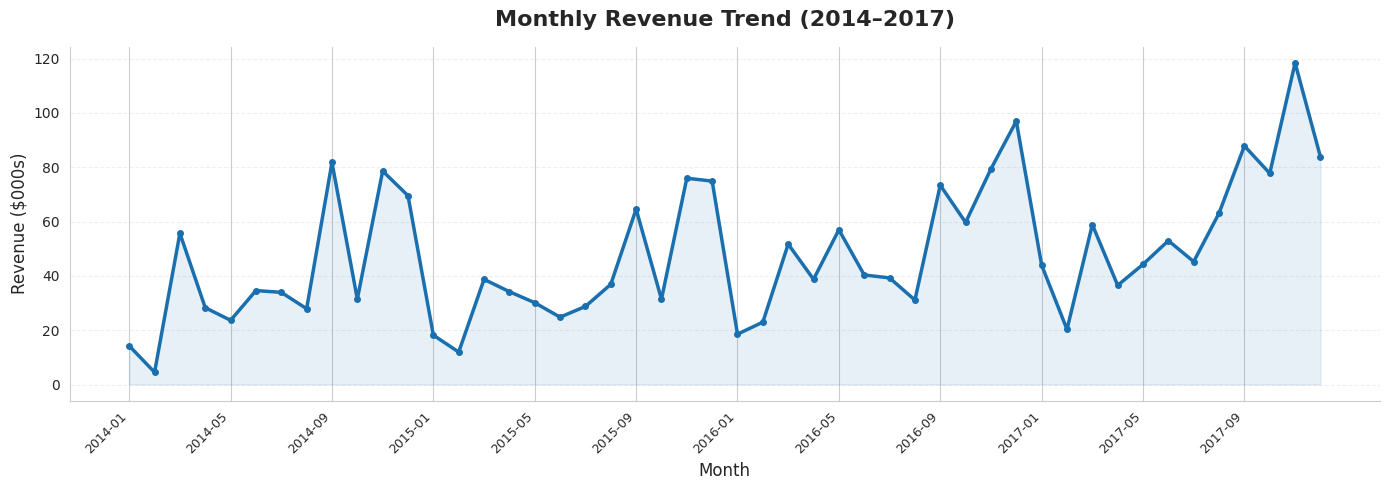

In [31]:
# =====================
# REVENUE TREND OVER TIME
# =====================
monthly_sales = df.groupby('Month_Year')['Sales'].sum().reset_index()
monthly_sales['Month_Year'] = monthly_sales['Month_Year'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(monthly_sales)),
        monthly_sales['Sales']/1000,
        color='#1a6faf', linewidth=2.5,
        marker='o', markersize=4)
ax.fill_between(range(len(monthly_sales)),
                monthly_sales['Sales']/1000,
                alpha=0.1, color='#1a6faf')
ax.set_title('Monthly Revenue Trend (2014–2017)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Revenue ($000s)', fontsize=12)
ax.set_xticks(range(0, len(monthly_sales), 6))
ax.set_xticklabels(monthly_sales['Month_Year'][::6],
                   rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(range(0, len(monthly_sales), 4))
ax.set_xticklabels(monthly_sales['Month_Year'][::4],
                   rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('revenue_trend.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

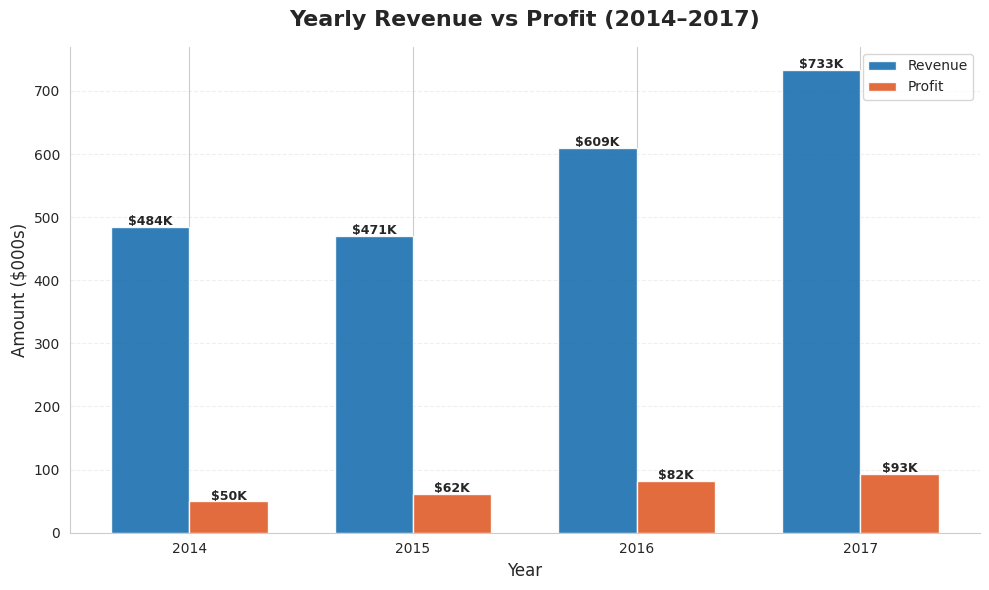

In [32]:
# =====================
# YEARLY PERFORMANCE
# =====================
yearly = df.groupby('Year')[['Sales','Profit']].sum().reset_index()

import numpy as np
x = np.arange(len(yearly))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, yearly['Sales']/1000,
               width, label='Revenue',
               color='#1a6faf', alpha=0.9)
bars2 = ax.bar(x + width/2, yearly['Profit']/1000,
               width, label='Profit',
               color='#e05c2a', alpha=0.9)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 3,
            f'${bar.get_height():,.0f}K',
            ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 3,
            f'${bar.get_height():,.0f}K',
            ha='center', fontsize=9, fontweight='bold')

ax.set_title('Yearly Revenue vs Profit (2014–2017)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Amount ($000s)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(yearly['Year'])
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('yearly_performance.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

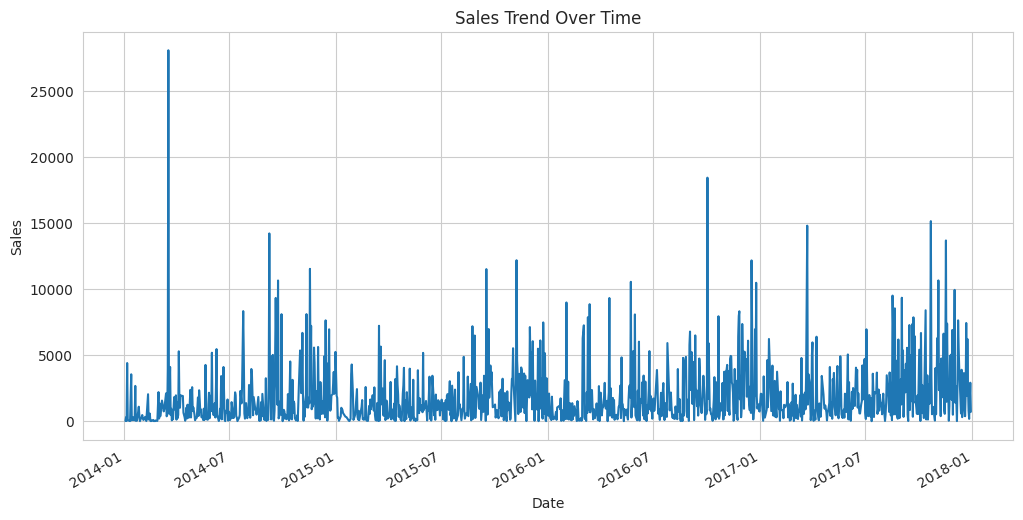

In [33]:
#Sales Trend Over Time
sales_trend = df.groupby('Order Date')['Sales'].sum()

plt.figure(figsize=(12,6))
sales_trend.plot()
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()



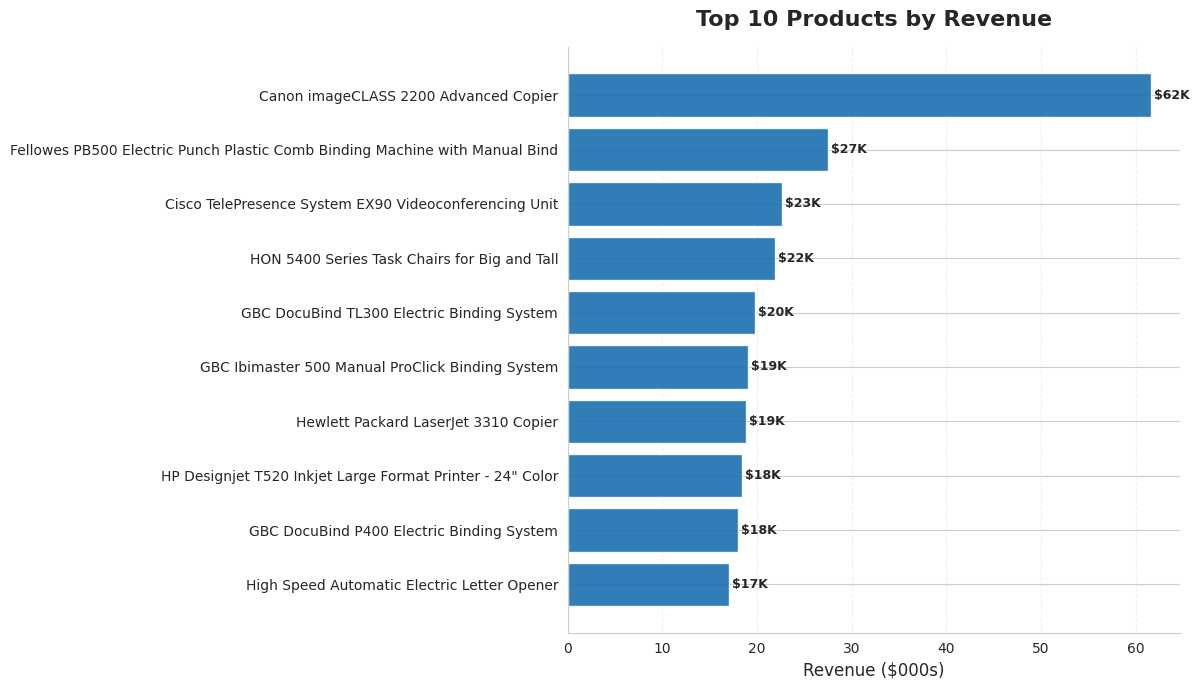

In [34]:
# =====================
# TOP 10 PRODUCTS
# =====================
top_products = df.groupby('Product Name')['Sales']\
                 .sum().sort_values(ascending=False)\
                 .head(10).reset_index()

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_products['Product Name'],
               top_products['Sales']/1000,
               color='#1a6faf', alpha=0.9)
for bar in bars:
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'${bar.get_width():,.0f}K',
            va='center', fontsize=9, fontweight='bold')
ax.set_title('Top 10 Products by Revenue',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Revenue ($000s)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('top_products.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

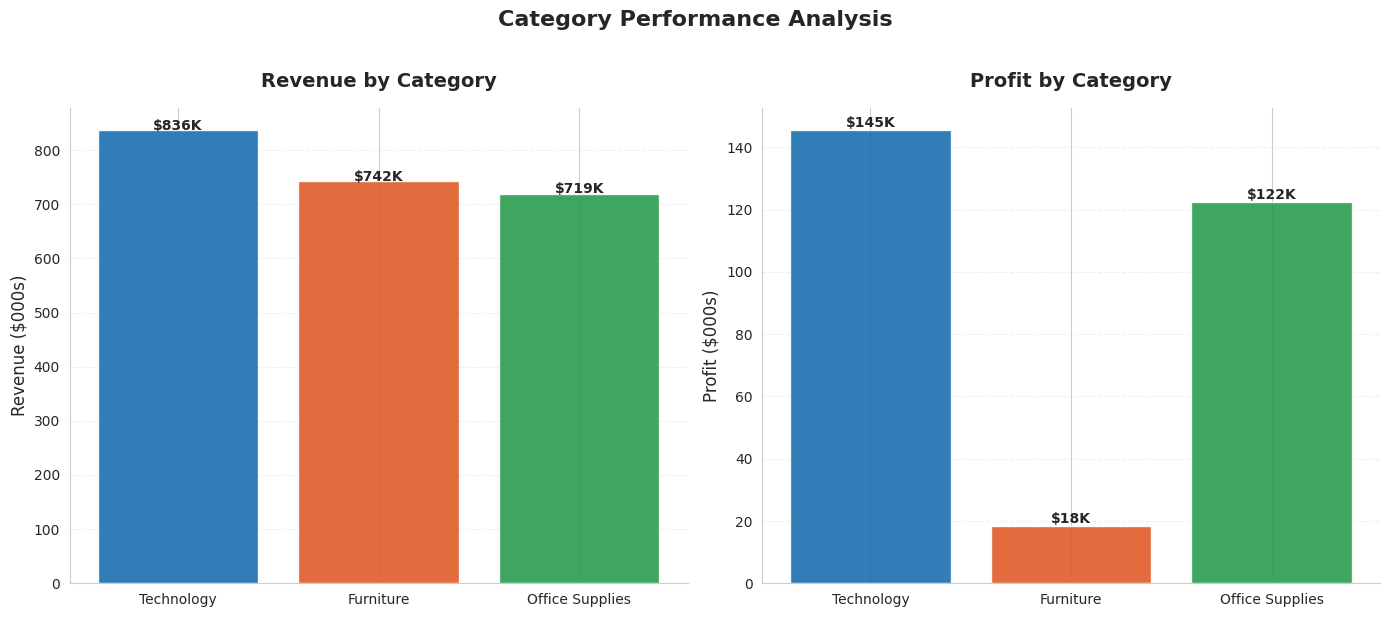

In [35]:
# =====================
# CATEGORY ANALYSIS
# =====================
category_data = df.groupby('Category')[['Sales','Profit']].sum().reset_index()
category_data = category_data.sort_values('Sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Revenue by Category
axes[0].bar(category_data['Category'],
            category_data['Sales']/1000,
            color=['#1a6faf','#e05c2a','#2a9d4e'], alpha=0.9)
for i, v in enumerate(category_data['Sales']/1000):
    axes[0].text(i, v + 1, f'${v:,.0f}K',
                ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Revenue by Category', fontsize=14,
                  fontweight='bold', pad=15)
axes[0].set_ylabel('Revenue ($000s)', fontsize=12)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Profit by Category
axes[1].bar(category_data['Category'],
            category_data['Profit']/1000,
            color=['#1a6faf','#e05c2a','#2a9d4e'], alpha=0.9)
for i, v in enumerate(category_data['Profit']/1000):
    axes[1].text(i, v + 1, f'${v:,.0f}K',
                ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Profit by Category', fontsize=14,
                  fontweight='bold', pad=15)
axes[1].set_ylabel('Profit ($000s)', fontsize=12)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Category Performance Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('category_analysis.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

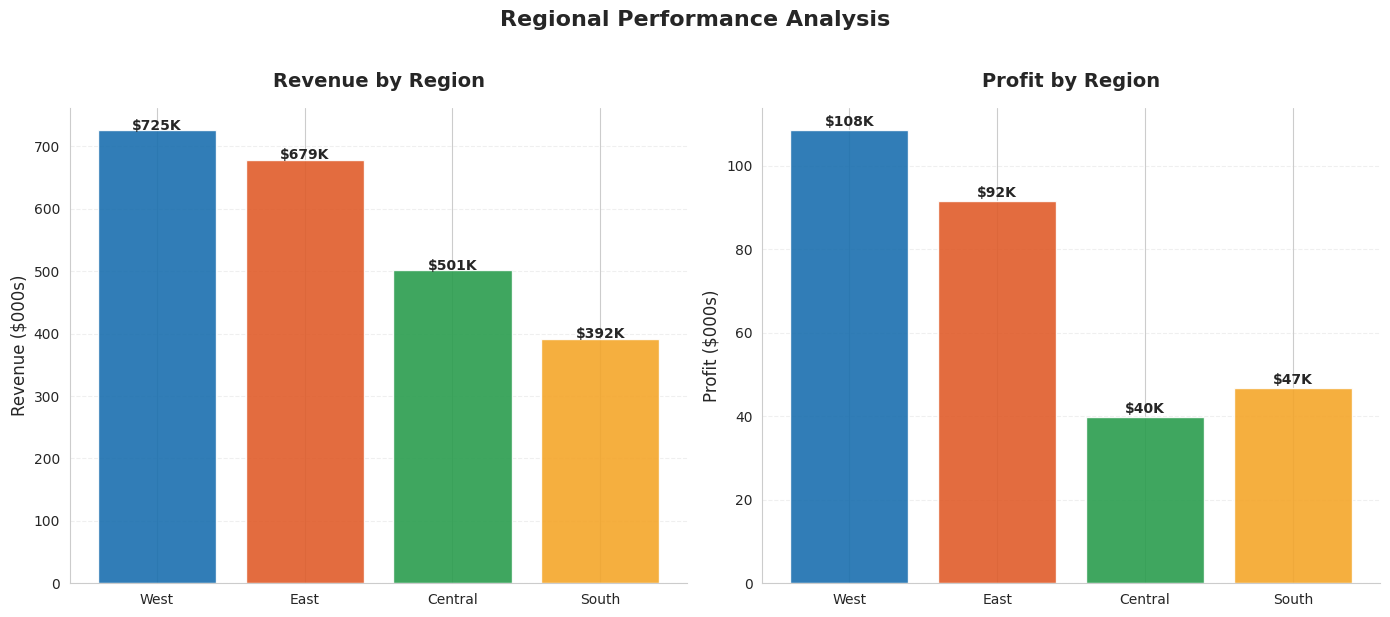

In [36]:
# =====================
# REGIONAL ANALYSIS
# =====================
region_data = df.groupby('Region')[['Sales','Profit']].sum().reset_index()
region_data = region_data.sort_values('Sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Revenue by Region
axes[0].bar(region_data['Region'],
            region_data['Sales']/1000,
            color=['#1a6faf','#e05c2a','#2a9d4e','#f4a62a'], alpha=0.9)
for i, v in enumerate(region_data['Sales']/1000):
    axes[0].text(i, v + 1, f'${v:,.0f}K',
                ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Revenue by Region', fontsize=14,
                  fontweight='bold', pad=15)
axes[0].set_ylabel('Revenue ($000s)', fontsize=12)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Profit by Region
axes[1].bar(region_data['Region'],
            region_data['Profit']/1000,
            color=['#1a6faf','#e05c2a','#2a9d4e','#f4a62a'], alpha=0.9)
for i, v in enumerate(region_data['Profit']/1000):
    axes[1].text(i, v + 1, f'${v:,.0f}K',
                ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Profit by Region', fontsize=14,
                  fontweight='bold', pad=15)
axes[1].set_ylabel('Profit ($000s)', fontsize=12)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Regional Performance Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('regional_analysis.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

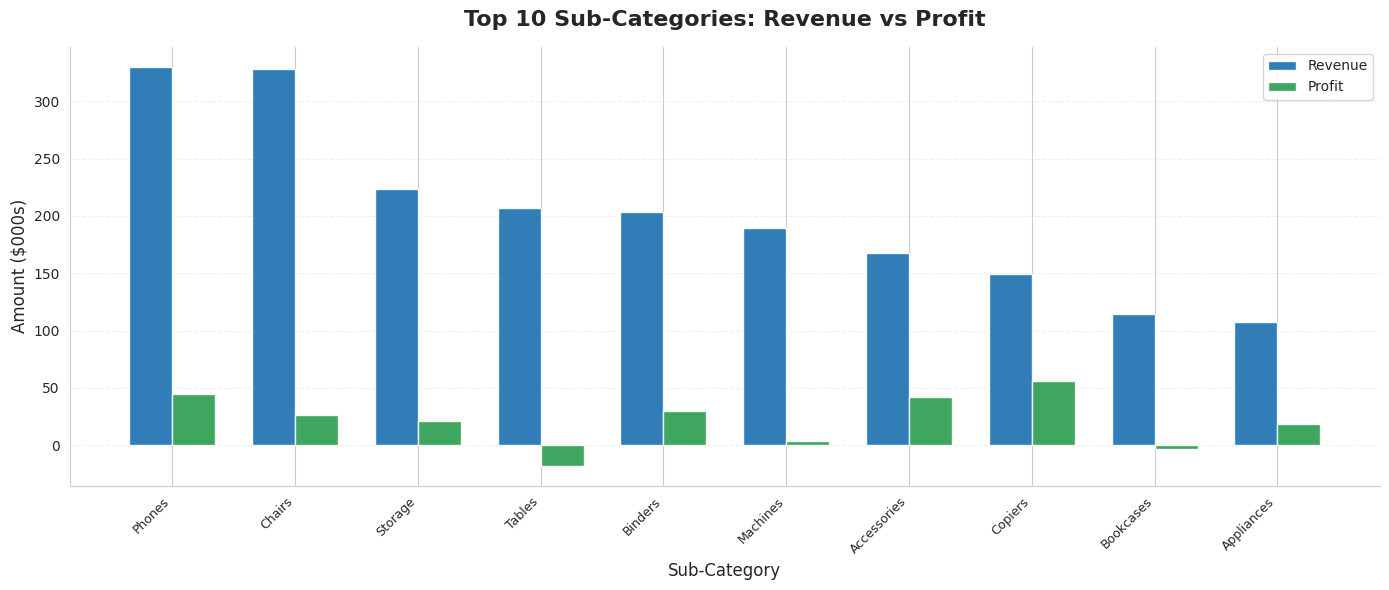

In [37]:
# =====================
# SUB-CATEGORY ANALYSIS
# =====================
subcategory = df.groupby('Sub-Category')[['Sales','Profit']]\
                .sum().sort_values('Sales', ascending=False)\
                .head(10).reset_index()

x = np.arange(len(subcategory))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, subcategory['Sales']/1000,
               width, label='Revenue',
               color='#1a6faf', alpha=0.9)
bars2 = ax.bar(x + width/2, subcategory['Profit']/1000,
               width, label='Profit',
               color='#2a9d4e', alpha=0.9)

ax.set_title('Top 10 Sub-Categories: Revenue vs Profit',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Sub-Category', fontsize=12)
ax.set_ylabel('Amount ($000s)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(subcategory['Sub-Category'],
                   rotation=45, ha='right', fontsize=9)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('subcategory_analysis.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

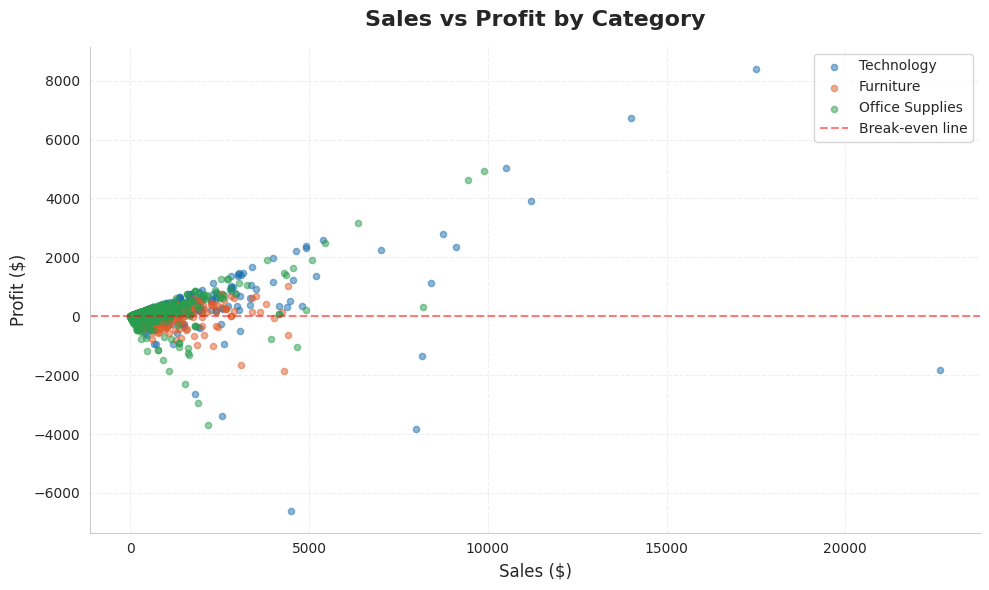

In [38]:
# =====================
# SALES VS PROFIT ANALYSIS
# =====================
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'Technology':'#1a6faf',
          'Furniture':'#e05c2a',
          'Office Supplies':'#2a9d4e'}

for category, color in colors.items():
    mask = df['Category'] == category
    ax.scatter(df[mask]['Sales'],
               df[mask]['Profit'],
               c=color, label=category,
               alpha=0.5, s=20)

ax.axhline(y=0, color='red', linestyle='--',
           alpha=0.5, label='Break-even line')
ax.set_title('Sales vs Profit by Category',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Sales ($)', fontsize=12)
ax.set_ylabel('Profit ($)', fontsize=12)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('sales_vs_profit.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

##  Section 6: Business Insights & Recommendations
Key findings and actionable recommendations based on the analysis.

In [39]:
# =====================
# FINAL INSIGHTS & RECOMMENDATIONS
# =====================
insights = """
╔══════════════════════════════════════════════════╗
║     BUSINESS SALES PERFORMANCE ANALYTICS        ║
║            EXECUTIVE SUMMARY                    ║
╚══════════════════════════════════════════════════╝

 KPI HIGHLIGHTS
─────────────────
  Total Revenue:    $2,297,200.86
  Total Profit:     $286,397.02
  Profit Margin:    12.47%
  Total Orders:     5,009
  Total Customers:  793

 KEY INSIGHTS
───────────────
1. REVENUE TREND
    Revenue grew 51% from $484K (2014) to $733K (2017)
    Consistent Q4 seasonal peaks every year
    January & February consistently weakest months

2. CATEGORY PERFORMANCE
    Technology leads: $836K revenue, $145K profit (17% margin)
    Office Supplies: Strong 17% profit margin
    Furniture WARNING: $742K revenue, only $18K profit (2.5% margin)

3. REGIONAL PERFORMANCE
    West leads: $725K revenue, $108K profit
    Central: High revenue but low profit — excessive discounting
    South: Lowest revenue at $392K — needs attention

4. TOP PRODUCTS
    Canon imageCLASS 2200 Copier — highest revenue at $60K+
    Technology products dominate top 10 list

5. PROFITABILITY
    1,871 transactions recorded losses due to high discounts
    Maximum discount of 80% is severely impacting profitability

 RECOMMENDATIONS
──────────────────
1.  REDUCE FURNITURE DISCOUNTS — margin critically low at 2.5%
2.  EXPAND TECHNOLOGY PRODUCTS — best profit margin at 17%
3.  BOOST SOUTH REGION — launch targeted marketing campaign
4.  LEVERAGE Q4 PEAKS — plan inventory ahead of Q4 season
5.  FIX CENTRAL REGION — audit discount practices immediately
"""
print(insights)

# Save to file
with open('insights_report.txt', 'w') as f:
    f.write(insights)



╔══════════════════════════════════════════════════╗
║     BUSINESS SALES PERFORMANCE ANALYTICS        ║
║            EXECUTIVE SUMMARY                    ║
╚══════════════════════════════════════════════════╝

 KPI HIGHLIGHTS
─────────────────
  Total Revenue:    $2,297,200.86
  Total Profit:     $286,397.02
  Profit Margin:    12.47%
  Total Orders:     5,009
  Total Customers:  793

 KEY INSIGHTS
───────────────
1. REVENUE TREND
    Revenue grew 51% from $484K (2014) to $733K (2017)
    Consistent Q4 seasonal peaks every year
    January & February consistently weakest months

2. CATEGORY PERFORMANCE
    Technology leads: $836K revenue, $145K profit (17% margin)
    Office Supplies: Strong 17% profit margin
    Furniture WARNING: $742K revenue, only $18K profit (2.5% margin)

3. REGIONAL PERFORMANCE
    West leads: $725K revenue, $108K profit
    Central: High revenue but low profit — excessive discounting
    South: Lowest revenue at $392K — needs attention

4. TOP PRODUCTS
    Ca